In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt

seed = torch.manual_seed(1234)

In [2]:
def plot_pinn(
    x_test,
    u_exact,
    u_pred,
    x_physics,
    y_physics,
    x_boundary,
    y_boundary,
    n_epochs,
    loss_history,
):
    plt.figure(figsize=(10, 6))

    # Wykres funkcji dokładnej oraz przybliżonej.
    plt.subplot(3, 1, 1)
    plt.plot(x_test, u_exact, label="Dokładne rozwiązanie", color="tab:grey", alpha=0.6)
    plt.plot(x_test, u_pred, label="Rozwiązanie PINN", color="tab:blue")
    plt.scatter(
        x_boundary,
        y_boundary,
        s=20,
        lw=0,
        color="tab:red",
        alpha=0.6,
        label="Warunek początkowy",
    )
    plt.title(f"Rozwiązanie PINN ({n_epochs} kroków)")
    plt.legend()
    plt.grid(True)
    plt.xlabel("x")
    plt.ylabel("u(x)")

    # Wykres funkcji błędu.
    plt.subplot(3, 1, 2)
    error = u_exact - u_pred
    plt.plot(x_test, error, label="Błąd", color="tab:orange")
    plt.title("Wykres funkcji błędu")
    plt.xlabel("x")
    plt.ylabel("Błąd")
    plt.legend()
    plt.grid(True)

    # Wykres funkcji kosztu w zależności od liczby epok.
    plt.subplot(3, 1, 3)
    plt.semilogy(
        range(n_epochs + 1), loss_history, label="Funkcja kosztu", color="tab:green"
    )
    plt.title("Wykres funkcji kosztu w zależności od liczby epok")
    plt.xlabel("Epoka")
    plt.ylabel("Koszt")
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

In [3]:
def plot_compare(label_1, data_1, label_2, data_2):
    (
        x_test_1,
        u_exact_1,
        u_pred_1,
        x_physics_1,
        y_physics_1,
        x_boundary_1,
        y_boundary_1,
        n_epochs_1,
        loss_history_1,
    ) = data_1

    (
        x_test_2,
        u_exact_2,
        u_pred_2,
        x_physics_2,
        y_physics_2,
        x_boundary_2,
        y_boundary_2,
        n_epochs_2,
        loss_history_2,
    ) = data_2

    plt.figure(figsize=(10, 6))

    # Wykres funkcji dokładnej oraz przybliżonej.
    plt.subplot(3, 1, 1)
    plt.plot(
        x_test_1, u_exact_1, label="Dokładne rozwiązanie", color="tab:grey", alpha=0.6
    )
    plt.plot(x_test_1, u_pred_1, label=f"Rozwiązanie {label_1}", color="tab:blue")
    plt.plot(x_test_2, u_pred_2, label=f"Rozwiązanie {label_2}", color="tab:green")
    plt.scatter(
        x_boundary_1,
        y_boundary_1,
        s=20,
        lw=0,
        color="tab:red",
        alpha=0.6,
        label="Warunek początkowy",
    )
    plt.title(f"Porównanie rozwiązań PINN ({n_epochs_1} kroków)")
    plt.legend()
    plt.grid(True)
    plt.xlabel("x")
    plt.ylabel("u(x)")

    # Wykres funkcji błędu.
    plt.subplot(3, 1, 2)
    error_1 = u_exact_1 - u_pred_1
    error_2 = u_exact_2 - u_pred_2
    plt.plot(x_test_1, error_1, label=f"Błąd {label_1}", color="tab:orange")
    plt.plot(x_test_2, error_2, label=f"Błąd {label_2}", color="tab:purple")
    plt.title("Wykres funkcji błędu")
    plt.xlabel("x")
    plt.ylabel("Błąd")
    plt.legend()
    plt.grid(True)

    # Wykres funkcji kosztu w zależności od liczby epok.
    plt.subplot(3, 1, 3)
    plt.plot(
        range(n_epochs_1 + 1),
        loss_history_1,
        label=f"Funkcja kosztu {label_1}",
        color="tab:blue",
    )
    plt.plot(
        range(n_epochs_2 + 1),
        loss_history_2,
        label=f"Funkcja kosztu {label_2}",
        color="tab:green",
    )
    plt.title("Wykres funkcji kosztu w zależności od liczby epok")
    plt.xlabel("Epoka")
    plt.ylabel("Koszt")
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

# Zadanie 1

Dane jest równanie różniczkowe zwyczajne
$$
\frac{du(x)}{dx} = \cos(\omega x) \text{ dla } x \in \Omega \text{ ,} \tag{1}
$$
gdzie:

$x, \omega, u \in \mathbb{R}$,

$x$ to położenie,

$\Omega$ to dziedzina, na której rozwiązujemy równanie, $\Omega = \{ x | -2\pi \le x \le 2\pi \}$.

$u(\cdot)$ to funkcja, której postaci szukamy.

Warunek początkowy zdefiniowany jest następująco:
$$
u(0) = 0 \text{ .} \tag{2}
$$

Analityczna postać rozwiązania równania (1) z warunkiem początkowym (2) jest następująca:
$$
u(x) = \frac{1}{\omega} \sin(\omega x) \text{ .} \tag{3}
$$

Rozwiąż powyższe zagadnienie początkowe (1,2). Do rozwiązania użyj sieci neuronowych PINN (ang. *Physics-informed Neural Network*). Można wykorzystać szablon w `pytorch`-u lub bibliotekę `DeepXDE`.

Koszt rezydualny zdefiniowany jest następująco:
$$
\mathcal{L}_r(\theta) = \frac{1}{N} \sum_{i=1}^{N}{|| \frac{d\hat{u}(x)}{dx} - \cos(\omega x_i) ||^2} \text{ ,} \tag{4}
$$
gdzie $N$ jest liczbą punktów kolokacyjnych.

Koszt związany z warunkiem początkowym przyjmuje postać:
$$
\mathcal{L}_{IC}(\theta) = || \hat{u}(0) - 0 ||^2 \text{ .} \tag{5}
$$

Funkcja kosztu zdefiniowana jest następująco:
$$
\mathcal{L}(\theta) = \mathcal{L}_r(\theta) + \mathcal{L}_{IC}(\theta) \text{ .} \tag{6}
$$

Warstwa wejściowa sieci posiada $1$ neuron, reprezentujący zmienną $x$, Warstwa wyjściowa także posiada $1$ neuron, reprezentujący zmienną $\hat{u}(x)$. Uczenie trwa przez $50 000$ kroków algorytmem Adam ze stałą uczenia równą $0.001$. Jako funkcję aktywacji przyjmij tangens hiperboliczny, $\tanh$.

In [4]:
class PINN:
    @staticmethod
    def exact_solution(x, omega):
        return np.sin(omega * x) / omega

    class FCN(nn.Module):
        "Defines a fully-connected network in PyTorch"

        def __init__(self, N_INPUT, N_OUTPUT, N_HIDDEN, N_LAYERS):
            super().__init__()
            activation = nn.Tanh
            self.fcs = nn.Sequential(*[nn.Linear(N_INPUT, N_HIDDEN), activation()])
            self.fch = nn.Sequential(
                *[
                    nn.Sequential(*[nn.Linear(N_HIDDEN, N_HIDDEN), activation()])
                    for _ in range(N_LAYERS - 1)
                ]
            )
            self.fce = nn.Linear(N_HIDDEN, N_OUTPUT)

        def forward(self, x):
            x = self.fcs(x)
            x = self.fch(x)
            x = self.fce(x)
            return x

    def __init__(self, omega, n_epochs, lr, n_hidden, n_layers, n_train):
        self.omega = omega
        self.n_epochs = n_epochs
        self.lr = lr
        self.n_hidden = n_hidden
        self.n_layers = n_layers
        self.n_train = n_train
        self.loss_history = []

        self.pinn = self.FCN(1, 1, self.n_hidden, self.n_layers)
        self.optimiser = optim.Adam(self.pinn.parameters(), lr=self.lr)

        self.x_boundary = torch.tensor([0.0]).view(-1, 1).requires_grad_(True)
        self.a, self.b = -2 * np.pi, 2 * np.pi
        self.x_physics = (
            torch.linspace(self.a, self.b, n_train).view(-1, 1).requires_grad_(True)
        )

    def _loss_ic(self):
        u_boundary = self.pinn(self.x_boundary)
        return (torch.squeeze(u_boundary) - 0) ** 2

    def _loss_r(self):
        u_physics = self.pinn(self.x_physics)
        dudx = torch.autograd.grad(
            u_physics, self.x_physics, torch.ones_like(u_physics), create_graph=True
        )[0]
        return torch.mean((dudx - torch.cos(self.omega * self.x_physics)) ** 2)

    def train(self):
        for epoch in range(self.n_epochs + 1):
            self.optimiser.zero_grad()

            loss = self._loss_r() + self._loss_ic()
            loss.backward()
            self.optimiser.step()
            
            self.loss_history.append(loss.item())
            if epoch % (self.n_epochs // 10) == 0:
                print(f"Epoch {epoch}/{self.n_epochs}, Loss: {loss:.2e}")

    def predict(self, n_test):
        x_test = torch.linspace(self.a, self.b, n_test).view(-1, 1)
        with torch.no_grad():
            u_pred = self.pinn(x_test).detach().numpy()
            x_test = x_test.detach().numpy()
            u_exact = self.exact_solution(x_test, self.omega)
            x_physics = self.x_physics.detach().numpy()
            y_physics = np.zeros_like(x_physics)
            x_boundary = self.x_boundary.detach().numpy()
            y_boundary = np.zeros_like(x_boundary)
        return (
            x_test,
            u_exact,
            u_pred,
            x_physics,
            y_physics,
            x_boundary,
            y_boundary,
            self.n_epochs,
            self.loss_history,
        )

(a) Przypadek $\omega = 1$.

Ustal następujące warości:
- $2$ warstwy ukryte, $16$ neuronów w każdej warstwie
- liczba punktów treningowych: $200$
- liczba punktów testowych: $1000$

In [5]:
omega = 1
n_epochs = 50_000
lr = 0.001
n_hidden = 16
n_layers = 2
n_train = 200
n_test = 1000

pinn_a = PINN(omega, n_epochs, lr, n_hidden, n_layers, n_train)
pinn_a.train()

Epoch 0/50000, Loss: 4.70e-01
Epoch 5000/50000, Loss: 2.62e-05
Epoch 10000/50000, Loss: 5.60e-06
Epoch 15000/50000, Loss: 2.25e-06
Epoch 20000/50000, Loss: 1.50e-06
Epoch 25000/50000, Loss: 7.33e-07
Epoch 30000/50000, Loss: 4.41e-07
Epoch 35000/50000, Loss: 5.18e-07
Epoch 40000/50000, Loss: 2.22e-07
Epoch 45000/50000, Loss: 5.23e-05
Epoch 50000/50000, Loss: 8.08e-06


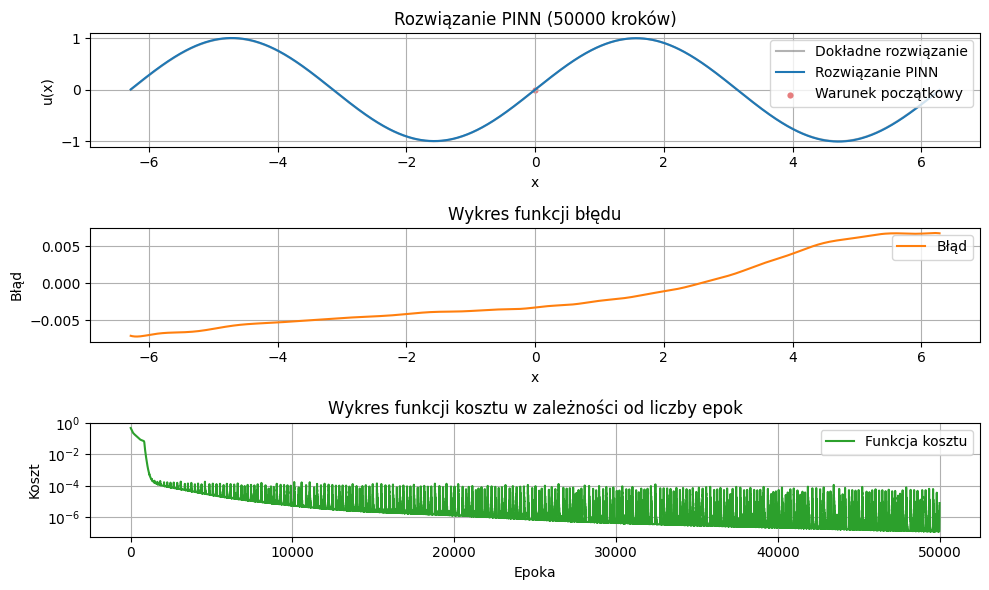

In [6]:
plot_pinn(*pinn_a.predict(n_test))

(b) Przypadek $\omega = 15$.

Ustal następujące wartości:
- liczba punktów treningowych: $200 \cdot 15 = 3000$
- liczba punktów testowych: $5000$

Eksperymenty przeprowadź z trzema architekturami sieci:
- $2$ warstwy ukryte, $16$ neuronów w każdej warstwie
- $4$ warstwy ukryte, $64$ neuronów w każdej warstwie
- $5$ warstwy ukryte, $128$ neuronów w każdej warstwie

In [7]:
omega = 15
n_epochs = 50_000
lr = 0.001
n_train = 3_000
n_test = 5_000

In [8]:
n_layers = 2
n_hidden = 16


pinn_b_2 = PINN(omega, n_epochs, lr, n_hidden, n_layers, n_train)
pinn_b_2.train()

Epoch 0/50000, Loss: 5.36e-01
Epoch 5000/50000, Loss: 5.00e-01
Epoch 10000/50000, Loss: 5.00e-01
Epoch 15000/50000, Loss: 5.00e-01
Epoch 20000/50000, Loss: 5.00e-01
Epoch 25000/50000, Loss: 5.00e-01
Epoch 30000/50000, Loss: 4.92e-01
Epoch 35000/50000, Loss: 4.45e-01
Epoch 40000/50000, Loss: 3.93e-01
Epoch 45000/50000, Loss: 2.90e-01
Epoch 50000/50000, Loss: 2.55e-01


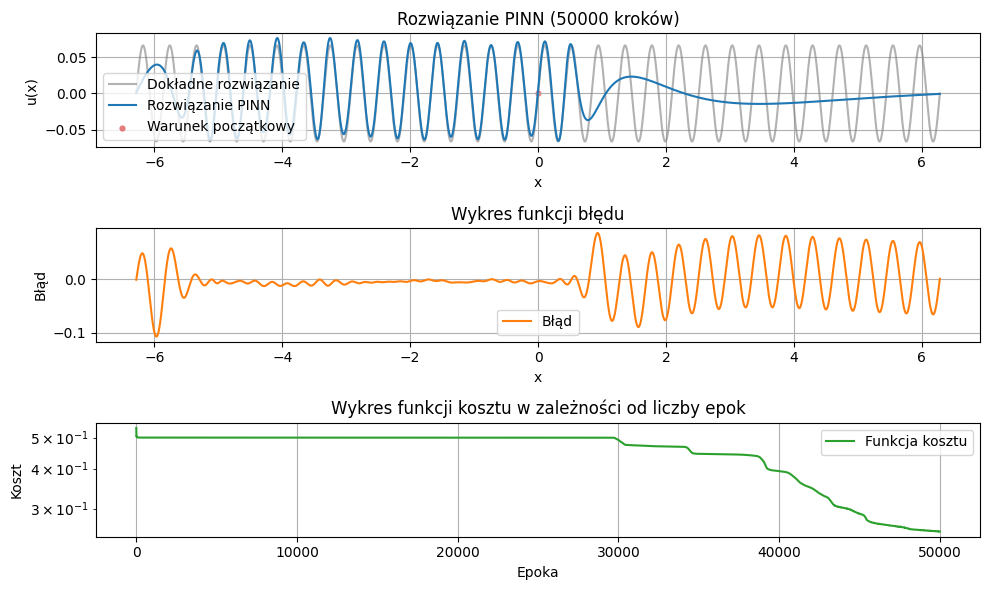

In [9]:
plot_pinn(*pinn_b_2.predict(n_test))

In [10]:
n_layers = 4
n_hidden = 64


pinn_b_4 = PINN(omega, n_epochs, lr, n_hidden, n_layers, n_train)
pinn_b_4.train()

Epoch 0/50000, Loss: 5.03e-01
Epoch 5000/50000, Loss: 5.00e-01
Epoch 10000/50000, Loss: 5.00e-01
Epoch 15000/50000, Loss: 3.34e-01
Epoch 20000/50000, Loss: 5.15e-02
Epoch 25000/50000, Loss: 2.24e-03
Epoch 30000/50000, Loss: 9.47e-04
Epoch 35000/50000, Loss: 6.75e-04
Epoch 40000/50000, Loss: 4.78e-04
Epoch 45000/50000, Loss: 2.04e-03
Epoch 50000/50000, Loss: 3.41e-03


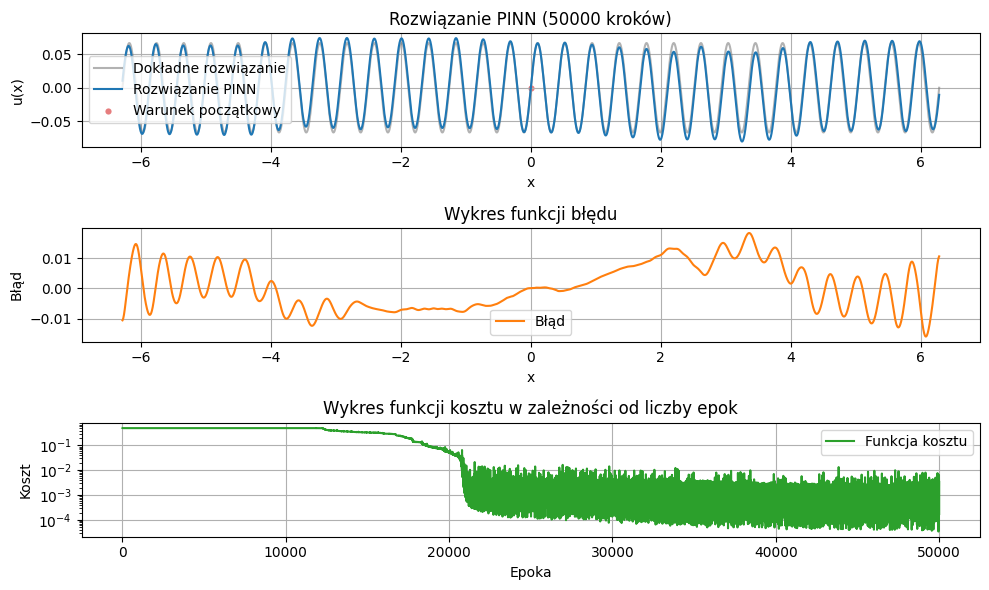

In [11]:
plot_pinn(*pinn_b_4.predict(n_test))

In [12]:
n_layers = 5
n_hidden = 128


pinn_b_5 = PINN(omega, n_epochs, lr, n_hidden, n_layers, n_train)
pinn_b_5.train()

Epoch 0/50000, Loss: 5.02e-01
Epoch 5000/50000, Loss: 5.00e-01
Epoch 10000/50000, Loss: 5.00e-01
Epoch 15000/50000, Loss: 5.00e-01
Epoch 20000/50000, Loss: 5.00e-01
Epoch 25000/50000, Loss: 9.05e-02
Epoch 30000/50000, Loss: 6.99e-05
Epoch 35000/50000, Loss: 9.10e-03
Epoch 40000/50000, Loss: 1.29e-02
Epoch 45000/50000, Loss: 3.47e-04
Epoch 50000/50000, Loss: 5.11e-03


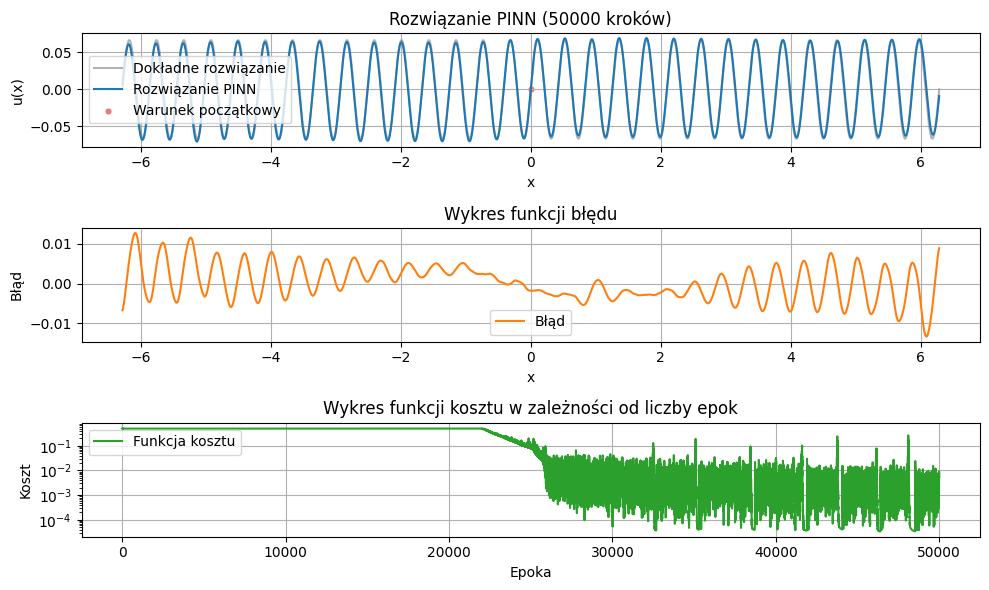

In [13]:
plot_pinn(*pinn_b_5.predict(n_test))

(c) Dla wybranej przez siebie sieci porównaj wyniki z rozwiązaniem, w którym przyjęto, że szukane rozwiązanie (*ansatz*) ma postać:
$$
\hat{u}(x;\theta) = \tanh(\omega x) \cdot NN(x;\theta) \text{ .} \tag{7}
$$
Taka postać rozwiązania gwarantuje spełnienie warunku $\hat{u}(0) = 0$ bez wprowadzania składnika $\mathcal{L}_{IC}$ do funkcji kosztu.

In [14]:
class PINNAnsatz(PINN):
    def __init__(self, omega, n_epochs, lr, n_hidden, n_layers, n_train):
        super().__init__(omega, n_epochs, lr, n_hidden, n_layers, n_train)

    def _ansatz(self, x):
        return torch.tanh(self.omega * x) * self.pinn(x)

    def _loss_r(self):
        u_physics = self._ansatz(self.x_physics)
        dudx = torch.autograd.grad(
            u_physics, self.x_physics, torch.ones_like(u_physics), create_graph=True
        )[0]
        return torch.mean((dudx - torch.cos(self.omega * self.x_physics)) ** 2)

    def _loss_ic(self):
        return torch.tensor(0.0)

In [15]:
compare_pinn = pinn_b_4

pinn_ansatz = PINNAnsatz(
    compare_pinn.omega,
    compare_pinn.n_epochs,
    compare_pinn.lr,
    compare_pinn.n_hidden,
    compare_pinn.n_layers,
    compare_pinn.n_train,
)
pinn_ansatz.train()

Epoch 0/50000, Loss: 5.50e-01
Epoch 5000/50000, Loss: 2.86e-01
Epoch 10000/50000, Loss: 1.84e-01
Epoch 15000/50000, Loss: 1.13e-01
Epoch 20000/50000, Loss: 7.23e-02
Epoch 25000/50000, Loss: 4.70e-02
Epoch 30000/50000, Loss: 3.65e-02
Epoch 35000/50000, Loss: 1.33e-02
Epoch 40000/50000, Loss: 5.15e-04
Epoch 45000/50000, Loss: 2.51e-03
Epoch 50000/50000, Loss: 3.28e-04


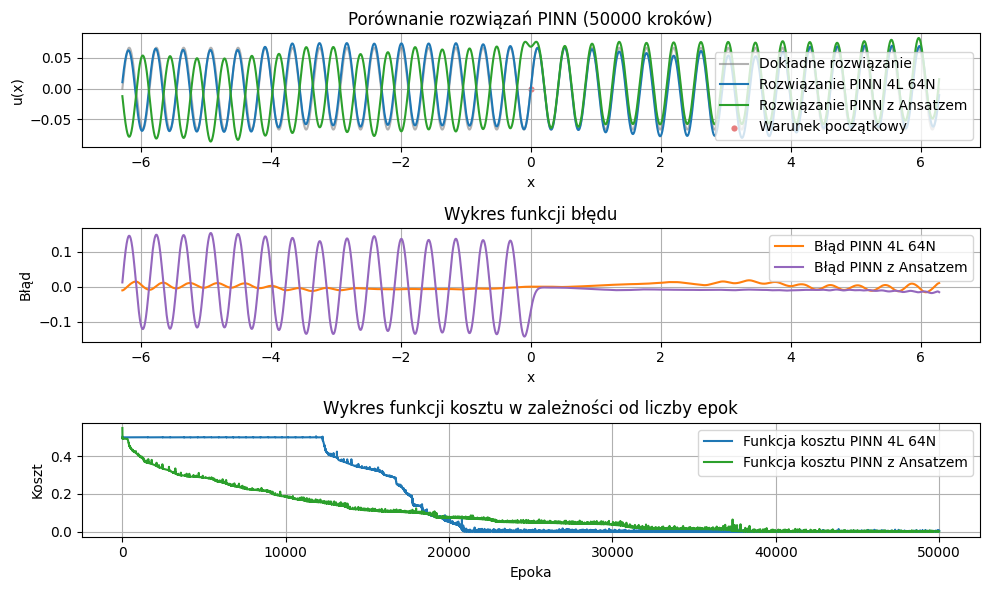

In [16]:
plot_compare("PINN 4L 64N", compare_pinn.predict(n_test), "PINN z Ansatzem", pinn_ansatz.predict(n_test))

(d) Porównaj pierwotny wynik z rozwiązaniem, w którym pierwszą warstwę ukrytą zainicjalizowano cechami Fouriera:
$$
\gamma(x) = \left[ \sin(2^0 \pi x), \cos(2^0 \pi x), ..., \sin(2^{L-1} \pi x), \cos(2^{L-1} \pi x) \right] \text{ .} \tag{8}
$$
Dobierz $L$ tak, aby nie zmieniać szerokości warstwy ukrytej.

In [17]:
class PINNFourier(PINN):
    def __init__(self, omega, n_epochs, lr, n_hidden, n_layers, n_train):
        super().__init__(omega, n_epochs, lr, n_hidden, n_layers, n_train)
        self._initialize_fourier_features()

    def _initialize_fourier_features(self):
        L = self.n_hidden // 2
        B = np.pi * np.array([2 ** i for i in range(L)])
        self.pinn.fcs[0].weight.data = torch.tensor(np.concatenate(
            [np.sin(B).reshape(-1, 1), np.cos(B).reshape(-1, 1)], axis=0), dtype=torch.float32)
        self.pinn.fcs[0].bias.data.fill_(0)

In [18]:
compare_pinn = pinn_b_4

pinn_fourier = PINNFourier(
    compare_pinn.omega,
    compare_pinn.n_epochs,
    compare_pinn.lr,
    compare_pinn.n_hidden,
    compare_pinn.n_layers,
    compare_pinn.n_train,
)
pinn_fourier.train()

Epoch 0/50000, Loss: 5.04e-01
Epoch 5000/50000, Loss: 2.00e-01
Epoch 10000/50000, Loss: 1.05e-01
Epoch 15000/50000, Loss: 5.89e-02
Epoch 20000/50000, Loss: 5.54e-04
Epoch 25000/50000, Loss: 3.62e-04
Epoch 30000/50000, Loss: 2.65e-04
Epoch 35000/50000, Loss: 5.07e-03
Epoch 40000/50000, Loss: 5.17e-04
Epoch 45000/50000, Loss: 4.35e-04
Epoch 50000/50000, Loss: 4.50e-03


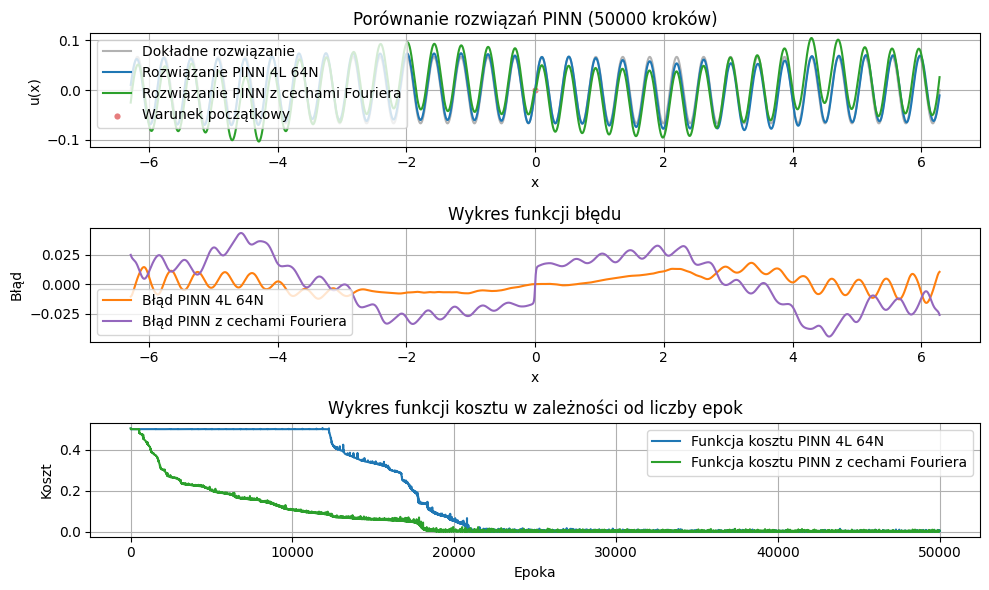

In [19]:
plot_compare("PINN 4L 64N", compare_pinn.predict(n_test), "PINN z cechami Fouriera", pinn_fourier.predict(n_test))

Dla każdego z powyższych przypadków stwórz następujące wykresy:
- Wykres funkcji $u(x)$, tj. dokładnego rozwiązania oraz wykres funkcji $\hat{u}(x)$, tj. rozwiązania znalezionego przez sieć neuronową
- Wykres funkcji błędu.

Stwórz także wykres funkcji kosztu w zależności od liczby epok.